In [ ]:
import pandas as pd
df = pd.read_excel("/content/online_retail_II.xlsx", sheet_name="Year 2009-2010")
print(df.shape)
print(df.head())

(525461, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [ ]:
print(df.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [ ]:
print(df.isnull().sum())




Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [ ]:
cancelled =df[df['Invoice'].astype(str).str.startswith('C')]
print("Cancelled orders:", len(cancelled))

Cancelled orders: 10206


In [ ]:
print("Negative quantities:", len(df[df['Quantity']<0]))

Negative quantities: 12326


In [ ]:
negative = len(df[df['Quantity']<0])
print("Negative quantities" , negative)

Negative quantities 12326


In [ ]:
zero = len(df[df['Price']<=0])
print("Xero or negative prices",zero )

Xero or negative prices 3690


In [ ]:
#data cleaning
df_clean= df[~df['Invoice'].astype(str).str.startswith('C')]
df_clean= df_clean[df_clean['Quantity']>0]
df_clean=df_clean[df_clean['Price']>0]

In [ ]:
df_clean=df_clean.dropna(subset=['Customer ID'])

In [ ]:
df_clean['Description']= df_clean['Description'].fillna('Unknown')

In [ ]:
df_clean['Customer ID']= df_clean['Customer ID'].astype(int)

In [ ]:
print("Clean dataset shape:", df_clean.shape)


Clean dataset shape: (407664, 8)


In [ ]:
print("Nulls Remaining:\n",df_clean.isnull().sum())

Nulls Remaining:
 Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [ ]:
df_clean['TotalPrice']= df_clean['Quantity'] * df_clean['Price']
df_clean['Year']=df_clean['InvoiceDate'].dt.year
df_clean['Month']=df_clean['InvoiceDate'].dt.month
df_clean['DayofWeek']= df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour']=df_clean['InvoiceDate'].dt.hour

In [ ]:
print(df_clean[['TotalPrice','Year','Month','DayofWeek','Hour']].head(10))

   TotalPrice  Year  Month DayofWeek  Hour
0        83.4  2009     12   Tuesday     7
1        81.0  2009     12   Tuesday     7
2        81.0  2009     12   Tuesday     7
3       100.8  2009     12   Tuesday     7
4        30.0  2009     12   Tuesday     7
5        39.6  2009     12   Tuesday     7
6        30.0  2009     12   Tuesday     7
7        59.5  2009     12   Tuesday     7
8        30.6  2009     12   Tuesday     7
9        45.0  2009     12   Tuesday     7


In [ ]:
print("Total Revenue in dataset : $ ", round(df_clean['TotalPrice'].sum(),2))

Total Revenue in dataset : $  8832003.27


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
monthly_revenue = df_clean.groupby(['Year','Month'])['TotalPrice'].sum().reset_index()
monthly_revenue['YearMonth']= monthly_revenue['Year'].astype(str)+'-'+monthly_revenue['Month'].astype(str).str.zfill(2)

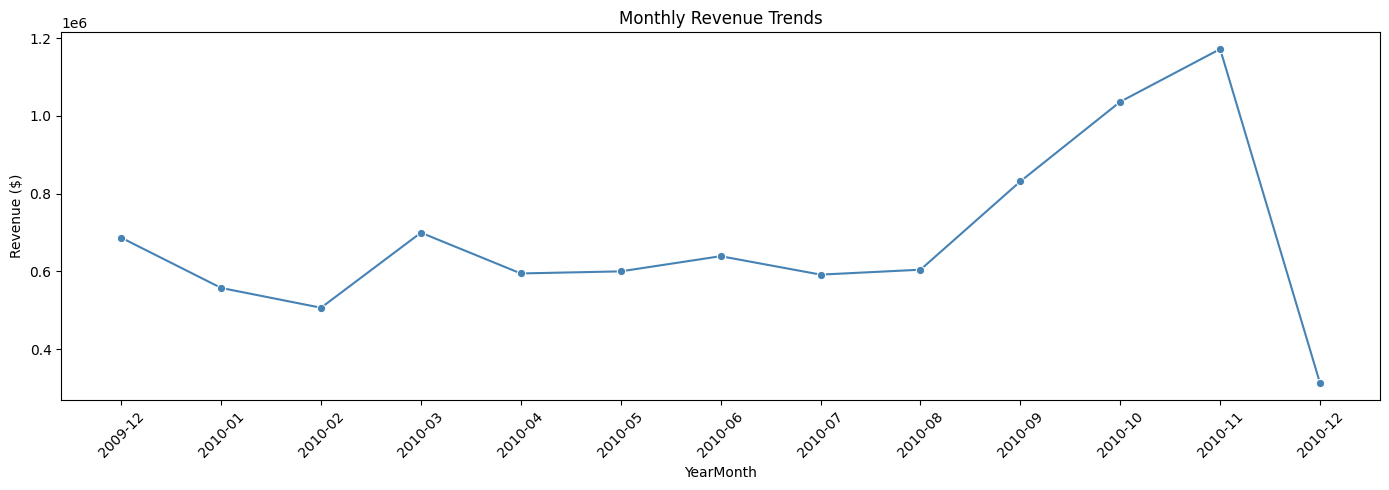

   YearMonth   TotalPrice
0    2009-12   686654.160
1    2010-01   557319.062
2    2010-02   506371.066
3    2010-03   699608.991
4    2010-04   594609.192
5    2010-05   599985.790
6    2010-06   639066.580
7    2010-07   591636.740
8    2010-08   604242.650
9    2010-09   831615.001
10   2010-10  1036680.000
11   2010-11  1172336.042
12   2010-12   311878.000


In [ ]:
plt.figure(figsize=(14,5))
sns.lineplot(data=monthly_revenue, x='YearMonth',y = 'TotalPrice',marker = 'o', color='steelblue')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trends' )
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig("monthly_revenue.png",dpi = 150)
plt.show()
print(monthly_revenue[['YearMonth','TotalPrice']])

/tmp/ipykernel_2842/3758675621.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products,x='Revenue',y='Product',palette='Blues_d')


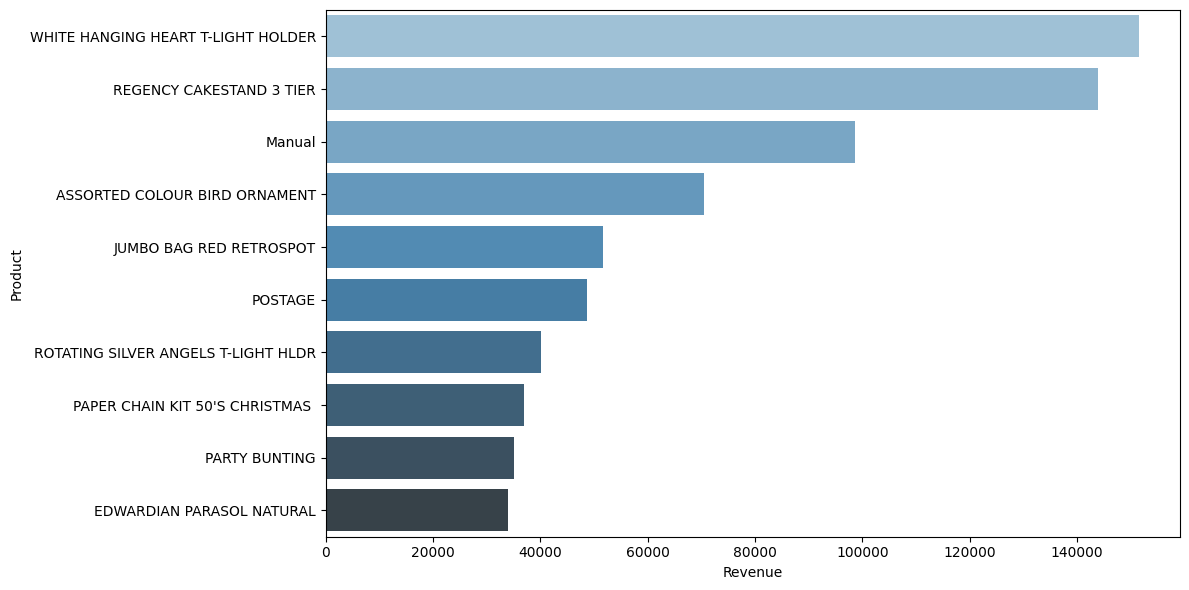

                               Product    Revenue
0   WHITE HANGING HEART T-LIGHT HOLDER  151624.31
1             REGENCY CAKESTAND 3 TIER  143893.35
2                               Manual   98560.64
3        ASSORTED COLOUR BIRD ORNAMENT   70493.83
4              JUMBO BAG RED RETROSPOT   51759.30
5                              POSTAGE   48741.08
6  ROTATING SILVER ANGELS T-LIGHT HLDR   40186.65
7      PAPER CHAIN KIT 50'S CHRISTMAS    36933.50
8                        PARTY BUNTING   35035.90
9            EDWARDIAN PARASOL NATURAL   34044.75


In [ ]:
top_products = df_clean.groupby('Description')['TotalPrice'].sum().sort_values(ascending = False).head(10).reset_index()
top_products.columns = ['Product','Revenue']
plt.figure(figsize= (12,6))
sns.barplot(data=top_products,x='Revenue',y='Product',palette='Blues_d')
plt.tight_layout()
plt.savefig('top_products.png',dpi=150)
plt.show()
print(top_products)


In [ ]:
top_countries = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending= False).head(10).reset_index()

/tmp/ipykernel_2842/3755995549.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='TotalPrice',y='Country',palette = "Greens_d")


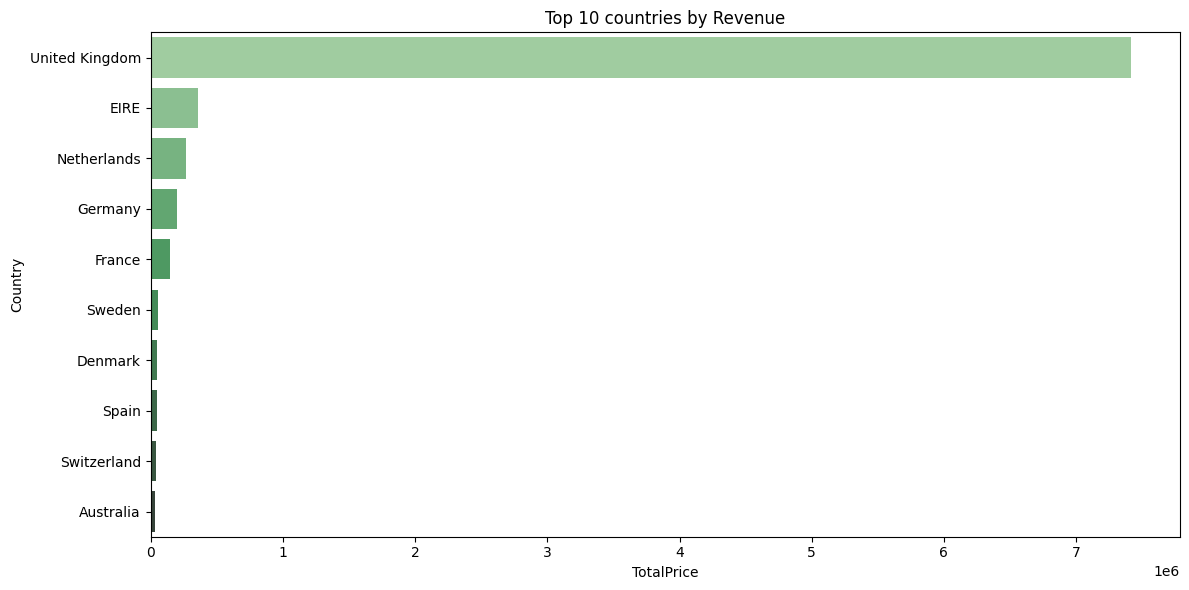

          Country   TotalPrice
0  United Kingdom  7414755.963
1            EIRE   356085.210
2     Netherlands   268786.000
3         Germany   202395.321
4          France   146215.420
5          Sweden    53171.390
6         Denmark    50906.850
7           Spain    47601.420
8     Switzerland    43921.390
9       Australia    31446.800


In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=top_countries, x='TotalPrice',y='Country',palette = "Greens_d")
plt.title("Top 10 countries by Revenue")
plt.tight_layout()
plt.savefig('topcountries.png',dpi= 150)
plt.show()
print(top_countries)


In [ ]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_revenue=df_clean.groupby("DayofWeek")['TotalPrice'].sum().reindex(day_order).reset_index()

/tmp/ipykernel_2842/4101632288.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_revenue,x='DayofWeek',y = 'TotalPrice',palette='Oranges_d')


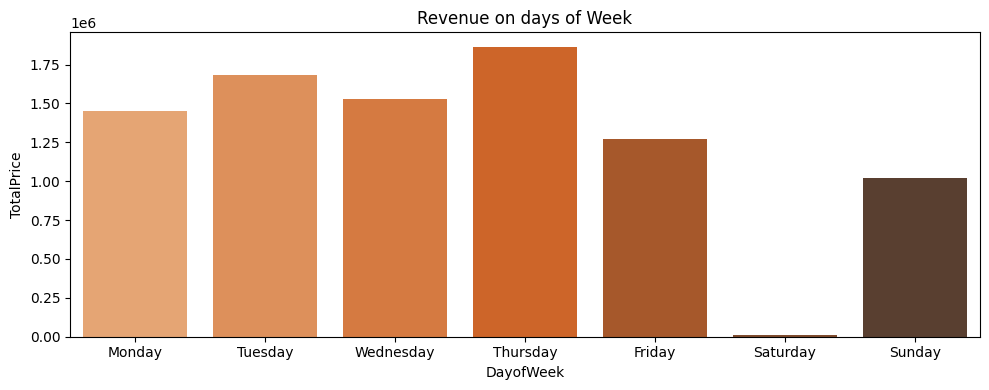

In [ ]:
plt.figure(figsize=(10,4))
sns.barplot(data=day_revenue,x='DayofWeek',y = 'TotalPrice',palette='Oranges_d')
plt.title("Revenue on days of Week")
plt.tight_layout()
plt.savefig("day_reveue.png",dpi=150)
plt.show()


In [ ]:
print(day_revenue.head())

   DayofWeek   TotalPrice
0     Monday  1450261.395
1    Tuesday  1684044.201
2  Wednesday  1527283.523
3   Thursday  1864223.892
4     Friday  1272488.092


/tmp/ipykernel_2842/2877594619.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=hour_revenue,x='Hour',y='TotalPrice',marker='o',palette='Purples_d')


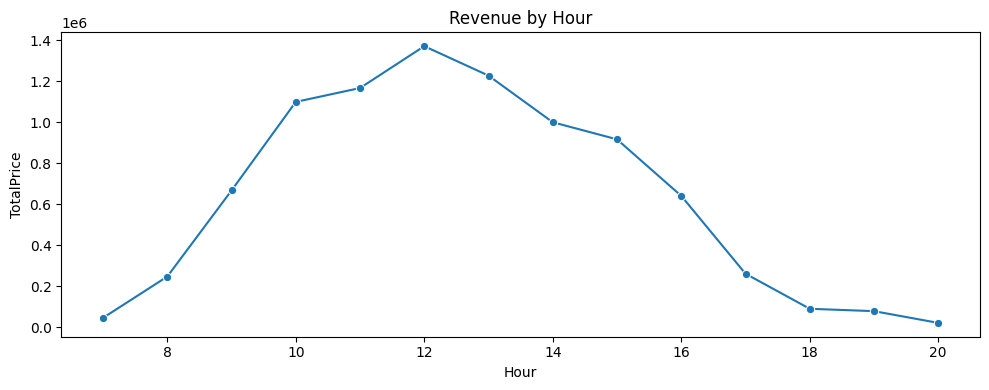

In [ ]:
hour_revenue = df_clean.groupby('Hour')['TotalPrice'].sum().reset_index()
plt.figure(figsize=(10,4))
sns.lineplot(data=hour_revenue,x='Hour',y='TotalPrice',marker='o',palette='Purples_d')
plt.title("Revenue by Hour")
plt.tight_layout()
plt.savefig("Revenuebyhour.png",dpi=150)
plt.show()

In [ ]:
df_clean[df_clean['Description'] == 'WHITE HANGING HEART T-LIGHT HOLDER'][['Quantity','Price','TotalPrice']].describe()

,Quantity,Price,TotalPrice
count,3153.000000,3153.000000,3153.000000
mean,18.051062,2.855690,48.088903
std,45.102509,0.171425,114.350346
min,1.000000,1.900000,2.950000
25%,4.000000,2.950000,11.800000
50%,6.000000,2.950000,17.700000
75%,18.000000,2.950000,53.100000
max,936.000000,3.240000,2386.800000


In [ ]:
top_countries = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
uk = top_countries['United Kingdom']
others = top_countries.drop('United Kingdom').sum()
print(f"UK Revenue: £{uk:,.0f}")
print(f"All others combined: £{others:,.0f}")
print(f"UK dominance: {uk/(uk+others)*100:.1f}%")

UK Revenue: £7,414,756
All others combined: £1,200,530
UK dominance: 86.1%


In [ ]:
avg_order = df_clean.groupby('Invoice')['TotalPrice'].sum().mean()
print(f"Average order value: £{avg_order:,.2f}")

Average order value: £459.69


In [ ]:
import datetime as dt
snapshot_date= df_clean['InvoiceDate'].max()+dt.timedelta(days=1)
print("Snapshot date: " , snapshot_date)

Snapshot date:  2010-12-10 20:01:00


In [ ]:
rfm = df_clean.groupby('Customer ID').agg({
  'InvoiceDate': lambda x:(snapshot_date - x.max()).days,
  'Invoice': 'nunique',
  'TotalPrice':'sum'
}).reset_index()
rfm.columns=['Customer ID','Recency','Frequency','Monetary']
print(rfm.shape)
print(rfm.describe)

(4312, 4)
<bound method NDFrame.describe of       Customer ID  Recency  Frequency  Monetary
0           12346      165         11    372.86
1           12347        3          2   1323.32
2           12348       74          1    222.16
3           12349       43          3   2671.14
4           12351       11          1    300.93
...           ...      ...        ...       ...
4307        18283       18          6    641.77
4308        18284       67          1    461.68
4309        18285      296          1    427.00
4310        18286      112          2   1296.43
4311        18287       18          4   2345.71

[4312 rows x 4 columns]>


In [ ]:
rfm['R_Score']=pd.qcut(rfm['Recency'],q=4,labels=[4,3,2,1])
rfm['F_Score']=pd.qcut(rfm['Frequency'].rank(method='first'),q=4,labels=[1,2,3,4])
rfm['M_Score']=pd.qcut(rfm['Monetary'],q=4,labels=[1,2,3,4])
rfm['RFM_Score']=rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)+rfm['M_Score'].astype(str)
print(rfm.head(10))

   Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0        12346      165         11    372.86       1       4       2       142
1        12347        3          2   1323.32       4       2       3       423
2        12348       74          1    222.16       2       1       1       211
3        12349       43          3   2671.14       3       3       4       334
4        12351       11          1    300.93       4       1       1       411
5        12352       11          2    343.80       4       2       2       422
6        12353       44          1    317.76       3       1       2       312
7        12355      203          1    488.21       1       1       2       112
8        12356       16          3   3562.25       4       3       4       434
9        12357       24          2  12079.99       3       2       4       324


In [ ]:
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'

    elif r > 4 and f >= 2:
        return 'Loyal Customers'

    elif r >= 3 and f <= 2:
        return 'Potentially Loyalist'

    elif r == 2:
        return 'AT RISK'

    else:
        return 'Lost'


rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [ ]:
segment_summary = rfm.groupby('Segment').agg(
    Count=('Customer ID', 'count'),
    Avg_Recency=('Recency','mean'),
    Avg_frequency=('Frequency','mean'),
    Avg_Monetary=('Monetary','mean')).round(1).reset_index()
print(segment_summary)

                Segment  Count  Avg_Recency  Avg_frequency  Avg_Monetary
0               AT RISK   1046         83.3            3.1        1222.5
1             Champions   1288         18.4            9.7        4970.0
2                  Lost   1259        208.5            2.0         621.8
3  Potentially Loyalist    719         27.4            1.4         513.2


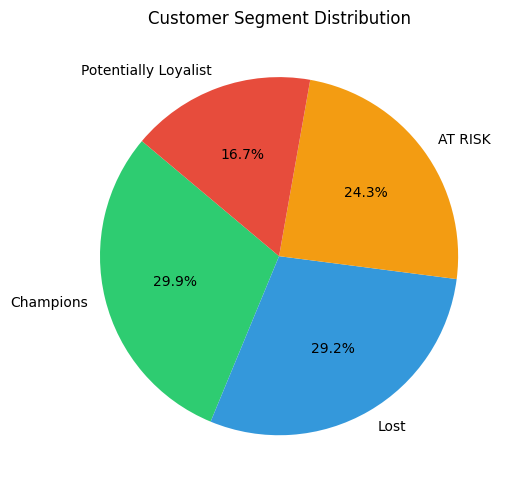

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,5))
seg_counts= rfm['Segment'].value_counts()
colors = ['#2ecc71','#3498db','#f39c12','#e74c3c','#9b59b6']
plt.pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Customer Segment Distribution')
plt.tight_layout()
plt.savefig('segments_pie.png', dpi=150)
plt.show()

/tmp/ipykernel_2842/3635196841.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm, x='Segment', y='Monetary', palette='Set2')


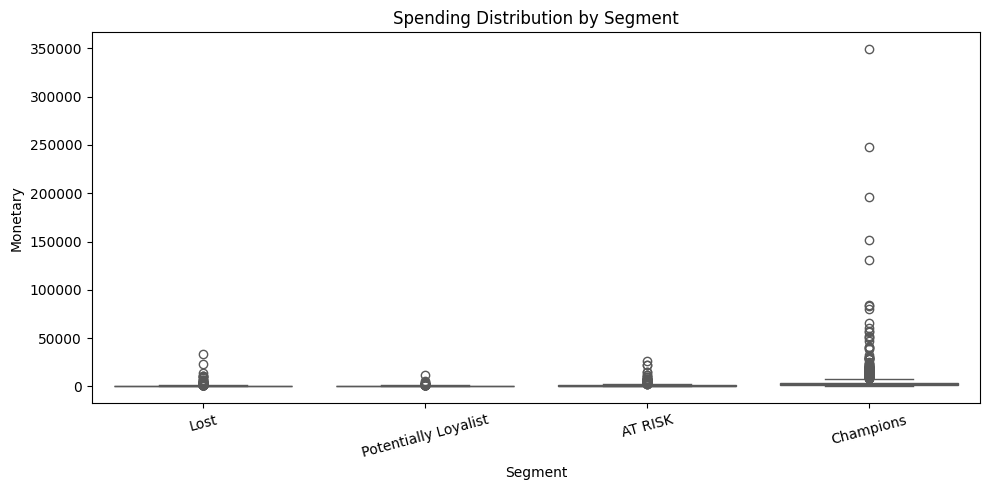

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=rfm, x='Segment', y='Monetary', palette='Set2')
plt.title('Spending Distribution by Segment')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('segments_box.png', dpi=150)
plt.show()

In [ ]:
lost_revenue = rfm[rfm['Segment'] == 'Lost']['Monetary'].sum()
atrisk_revenue = rfm[rfm['Segment'] == 'AT RISK']['Monetary'].sum()

print(f"Revenue at risk from Lost customers: £{lost_revenue:,.0f}")
print(f"Revenue at risk from At Risk customers: £{atrisk_revenue:,.0f}")
print(f"Total revenue being lost: £{lost_revenue + atrisk_revenue:,.0f}")


Revenue at risk from Lost customers: £782,858
Revenue at risk from At Risk customers: £1,278,768
Total revenue being lost: £2,061,626


In [ ]:
# Check exact segment names in your dataframe
print(rfm['Segment'].unique())
print(rfm['Segment'].value_counts())

['Lost' 'Potentially Loyalist' 'AT RISK' 'Champions']
Segment
Champions               1288
Lost                    1259
AT RISK                 1046
Potentially Loyalist     719
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

rfm_scaled = rfm[['Recency','Frequency','Monetary']].copy()
scaler = StandardScaler()
rfm_scaled_values = scaler.fit_transform(rfm_scaled)

print("Scaled data shape ",rfm_scaled_values.shape)
print("Mean after scaling (should be ~0):",rfm_scaled_values.mean(axis = 0).round(3))
print("Std after scaling (should be ~1):",rfm_scaled_values.std(axis=0).round(3))

Scaled data shape  (4312, 3)
Mean after scaling (should be ~0): [ 0.  0. -0.]
Std after scaling (should be ~1): [1. 1. 1.]


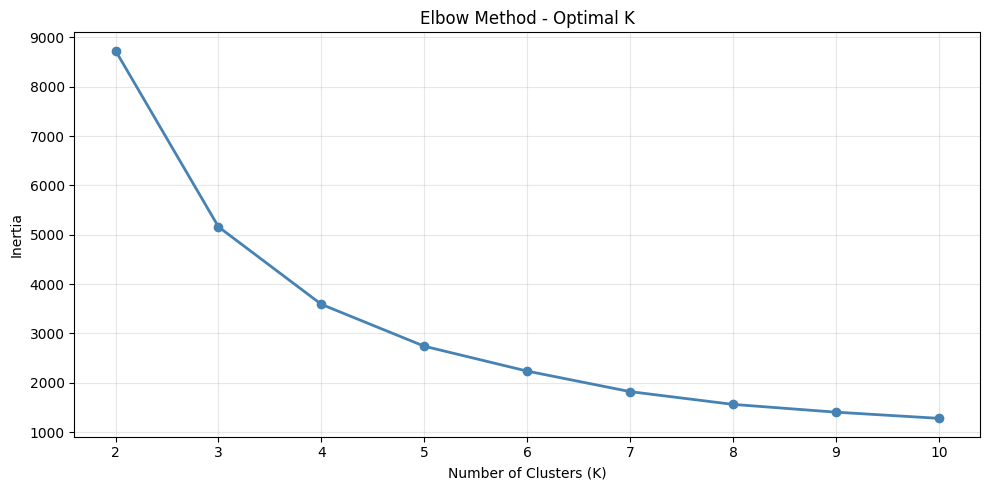

Inertia VALUES [8728.777543439755, 5158.586799307538, 3587.84558553649, 2738.8471204416032, 2234.5811936522377, 1818.6492734081298, 1559.9236377854843, 1402.2226114328914, 1277.1336752538596]


In [ ]:
inertia=[]
k_range  = range(2,11)
for k in k_range:
  kmeans = KMeans(n_clusters=k,random_state = 42,n_init=10)
  kmeans.fit(rfm_scaled_values)
  inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(k_range,inertia,marker='o',color='steelblue',linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Optimal K')
plt.xticks(k_range)
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_curve.png',dpi=150)
plt.show()

print('Inertia VALUES', inertia)

In [ ]:
K=4
kmeans = KMeans(n_clusters=K,random_state = 42,n_init=10)
rfm['KMeans_Cluster']=kmeans.fit_predict(rfm_scaled_values)

cluster_profile = rfm.groupby('KMeans_Cluster').agg(
    Count =('Customer ID','count'),
    Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Monetary=('Monetary','mean'),

).round(1).reset_index()
Name = {
    0: 'Core Customers',
    1: 'Churned',
    2: 'VIP Whales',
    3: 'High Value Loyalists'
}
cluster_profile['Segment_Name'] = cluster_profile['KMeans_Cluster'].map(Name)
rfm['Segment_Name'] = rfm['KMeans_Cluster'].map(Name)

print(cluster_profile[['Segment_Name', 'Count', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary']])

           Segment_Name  Count  Avg_Recency  Avg_Frequency  Avg_Monetary
0        Core Customers   3201         43.1            4.4        1710.8
1               Churned   1047        243.0            1.7         596.9
2            VIP Whales      5          5.6          113.6      215543.7
3  High Value Loyalists     59         14.3           46.0       28018.4


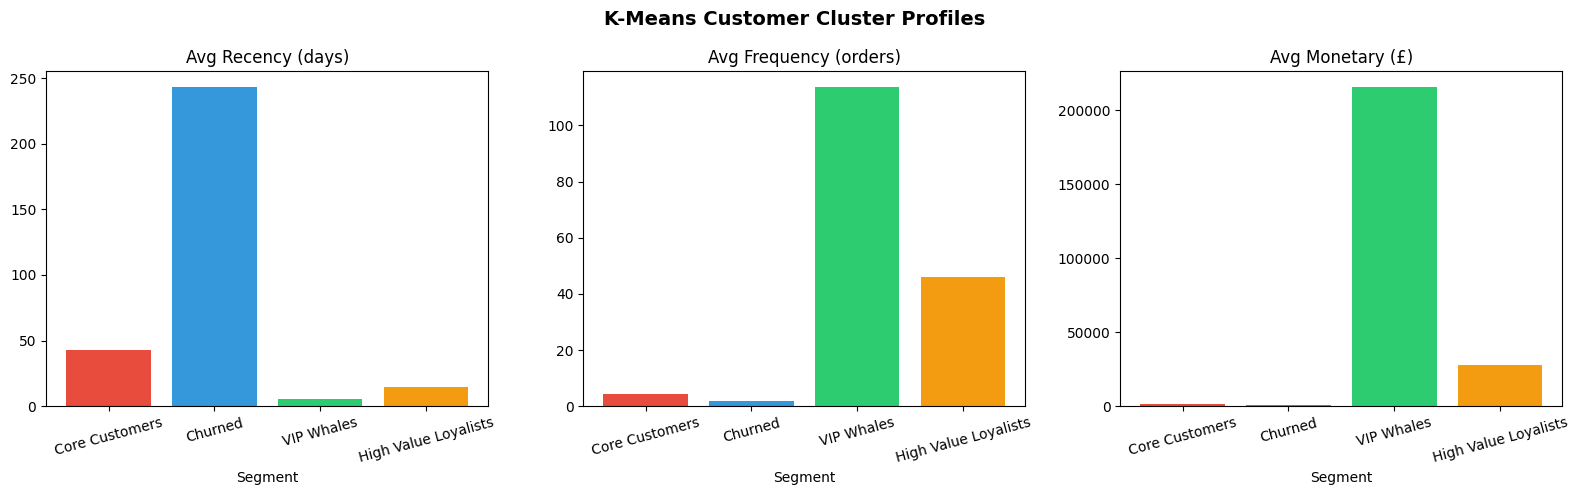

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary']
titles = ['Avg Recency (days)', 'Avg Frequency (orders)', 'Avg Monetary (£)']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    axes[i].bar(
        cluster_profile['Segment_Name'],
        cluster_profile[metric],
        color=colors
    )
    axes[i].set_title(title)
    axes[i].set_xlabel('Segment')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('K-Means Customer Cluster Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150)
plt.show()

In [ ]:
df_clean.to_csv('ecommerce_clean.csv',index = False)
rfm.to_csv('rfm_segments.csv',index = False)
cluster_profile.to_csv('cluster_profile.csv',index = False)

print("All files saved!")
print(f"Clean data:{len(df_clean):,} rows")
print(f"RFM customers:{len(rfm):,} customers")
print(f"Clusters:{len(cluster_profile)} segments")

All files saved!
Clean data:407,664 rows
RFM customers:4,312 customers
Clusters:4 segments
